In [19]:
import geopandas as gpd
import pandas as pd
from shapely.ops import substring, unary_union, linemerge
from shapely.geometry import Point, MultiLineString
import shapely

In [20]:
df = pd.read_csv('../data/final_sweep_df.csv')
df = df[['location', 'district', 'sensitivity_zone', 'intervention', 'operation_start_date',
       'operation_end_date', 'posting_id', 'sweep_event_id']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2206 entries, 0 to 2205
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   location              2206 non-null   object
 1   district              2206 non-null   object
 2   sensitivity_zone      2206 non-null   object
 3   intervention          2206 non-null   object
 4   operation_start_date  2206 non-null   object
 5   operation_end_date    2206 non-null   object
 6   posting_id            2206 non-null   int64 
 7   sweep_event_id        2206 non-null   object
dtypes: int64(1), object(7)
memory usage: 138.0+ KB


Ok i need each posting id to be associated with a polydot associated with rows on the combined.geojson

In [21]:
gdf = gpd.read_file('../data/combined_verified_sweeps.geojson')
gdf.info()

Skipping field district: unsupported OGR type: 5
Skipping field sensitivity_zone: unsupported OGR type: 5
Skipping field intervention_types: unsupported OGR type: 5
Skipping field operation_dates: unsupported OGR type: 5
Skipping field sweep_event_ids: unsupported OGR type: 5


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 796 entries, 0 to 795
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   location          796 non-null    object  
 1   num_postings      796 non-null    int32   
 2   posting_ids       796 non-null    object  
 3   number_of_sweeps  796 non-null    int32   
 4   geometry          796 non-null    geometry
dtypes: geometry(1), int32(2), object(2)
memory usage: 25.0+ KB


In [22]:
gdf.head()
print(f'there are {sum(gdf["num_postings"])} postings in the dataset')

there are 2200 postings in the dataset


In [23]:
lines = gdf[gdf['geometry'].type == 'LineString'].copy()

lines.to_crs(crs='EPSG:3857')

dist = 10
print(f'there are {sum(lines["num_postings"])} postings in the lines df')
print(f'there are {len(lines)} lines in the lines df')
lines.head()


there are 1724 postings in the lines df
there are 627 lines in the lines df


,location,num_postings,posting_ids,number_of_sweeps,geometry
0,Knight Street between Douglas Avenue and Grame...,1,[ 2046 ],1,"LINESTRING (-122.18129 37.72966, -122.18225 37..."
1,105th Ave between Russet St & San Leandro St,1,[ 879 ],1,"LINESTRING (-122.17514 37.73531, -122.17479 37..."
2,Railroad Ave between 85th Ave and Louisana St ...,3,[ 51 111 877],2,"LINESTRING (-122.18528 37.74069, -122.19083 37..."
3,E 12th St between 22nd Ave and 23rd Ave,1,[ 546 ],1,"LINESTRING (-122.23877 37.78366, -122.23682 37..."
4,Lake Merritt: Amphitheater/ 12th St between La...,1,[ 1241 ],1,"LINESTRING (-122.26187 37.799, -122.26231 37.7..."


In [24]:
import os
out_path = '../data/sweep_lines.geojson'
if os.path.exists(out_path):
    os.remove(out_path)
lines.to_file(out_path, driver='GeoJSON')


ok first i have to make two lines

In [25]:
OFFSET_DIST = 0.0001   # lateral spacing between the two rows
DOT_SPACING  = 0.00007  # fixed distance between dots along the line (degrees)
START_OFFSET = 0.00008  # padding before first dot at the start of the line

In [26]:
def clean_offset(geom, dist, side):
    offset = geom.parallel_offset(dist, side, join_style=2)
    offset = unary_union(offset)
    
    if isinstance(offset, MultiLineString):
        offset = linemerge(offset)
    if isinstance(offset, MultiLineString):
        offset = max(offset.geoms, key=lambda x: x.length)
    
    if side == 'right':
        offset = shapely.geometry.LineString(list(offset.coords)[::-1])
    
    # Force 2D after all reconstruction is done
    offset = shapely.force_2d(offset)
    
    # Guard before substring
    if offset is None or offset.is_empty or offset.length < 1e-6 or len(list(offset.coords)) < 2:
        return None

    offset = substring(offset, 0.1, 0.9, normalized=True)
    return offset

In [27]:
dot_rows = []

for _, row in lines.iterrows():
    n    = int(row['num_postings'])
    geom = row['geometry']

    mid_line     = shapely.force_2d(substring(geom, 0.1, 0.9, normalized=True))
    left_offset  = clean_offset(geom, OFFSET_DIST, 'left')
    right_offset = clean_offset(geom, OFFSET_DIST, 'right')

    def line_capacity(line):
        if line is None or line.is_empty:
            return 0
        return max(1, int((line.length - START_OFFSET) / DOT_SPACING) + 1)

    mid_cap   = line_capacity(mid_line)
    left_cap  = line_capacity(left_offset)
    right_cap = line_capacity(right_offset)

    # Fill middle first, then left, then right
    mid_count   = min(n, mid_cap)
    left_count  = min(n - mid_count, left_cap)
    right_count = min(n - mid_count - left_count, right_cap)

    for side, line, count in [
        ('middle', mid_line,     mid_count),
        ('left',   left_offset,  left_count),
        ('right',  right_offset, right_count),
    ]:
        if count == 0 or line is None or line.is_empty:
            continue
        for j in range(count):
            dist_along = START_OFFSET + j * DOT_SPACING
            if dist_along > line.length:
                break
            pt = line.interpolate(dist_along, normalized=False)
            dot_rows.append({
                'location':     row['location'],
                'num_postings': n,
                'side':         side,
                'dot_index':    j,
                'longitude':    pt.x,
                'latitude':     pt.y,
                'geometry':     pt,
            })

dots_gdf = gpd.GeoDataFrame(dot_rows, geometry='geometry', crs=lines.crs)
dots_gdf.drop(columns='geometry').to_csv('posting_dots.csv', index=False)

print(f"Generated {len(dots_gdf)} dots across {len(lines)} segments")


Generated 1724 dots across 627 segments


In [28]:
import os
out_path = '../data/posting_dots.geojson'
if os.path.exists(out_path):
    os.remove(out_path)
lines.to_file(out_path, driver='GeoJSON')


dots_gdf.to_file(out_path, driver='GeoJSON')

In [29]:
dots_gdf.head()

,location,num_postings,side,dot_index,longitude,latitude,geometry
0,Knight Street between Douglas Avenue and Grame...,1,middle,0,-122.181475,37.729738,POINT (-122.18147 37.72974)
1,105th Ave between Russet St & San Leandro St,1,middle,0,-122.175032,37.735353,POINT (-122.17503 37.73535)
2,Railroad Ave between 85th Ave and Louisana St ...,3,middle,0,-122.185894,37.741225,POINT (-122.18589 37.74122)
3,Railroad Ave between 85th Ave and Louisana St ...,3,middle,1,-122.185947,37.741271,POINT (-122.18595 37.74127)
4,Railroad Ave between 85th Ave and Louisana St ...,3,middle,2,-122.186000,37.741317,POINT (-122.186 37.74132)


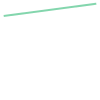

In [30]:
left_offset

current problems:

- the dots are too close together because of MLK & 23rd
- need to get them closer to the road
- they need to not overlap at any point of zoom

EVERYTHING BELOW THIS IS JUST GENERATING MAPS

In [31]:
# Download Oakland boundary and roads
import osmnx as ox

oakland = ox.geocode_to_gdf('Oakland, California, USA')
G = ox.graph_from_place('Oakland, California, USA', network_type='drive')
_, roads = ox.graph_to_gdfs(G)

In [32]:
import folium
import os


center_lat = 37.8044
center_lon = -122.2712

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None)

# City boundary
folium.GeoJson(
    oakland,
    style_function=lambda x: {
        'color': '#333333', 'weight': 2, 'fillOpacity': 0
    }
).add_to(m)

# Roads
folium.GeoJson(
    roads[['geometry']],
    style_function=lambda x: {
        'color': '#aaaaaa', 'weight': 0.5, 'opacity': 0.6
    }
).add_to(m)

for _, row in dots_gdf.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=None,
        fill=True,
        fill_color='#CC0000',
        fill_opacity=0.25,
    ).add_to(m)


m.save('oakland_base.html')
print("Saved")

os.startfile('oakland_base.html')


Saved


In [33]:
import folium
import os

center_lat = 37.8044
center_lon = -122.2712

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None)

# City boundary
folium.GeoJson(
    oakland,
    style_function=lambda x: {'color': '#333333', 'weight': 2, 'fillOpacity': 0}
).add_to(m)

# OSM roads (background)
folium.GeoJson(
    roads[['geometry']],
    style_function=lambda x: {'color': '#aaaaaa', 'weight': 0.5, 'opacity': 0.6}
).add_to(m)

# Sweep segments — thick outlines, added before dots so dots sit on top
sweep_layer = folium.GeoJson(
    lines[['location', 'geometry']],
    style_function=lambda x: {'color': '#CC0000', 'weight': 8, 'opacity': 0.25, 'fillOpacity': 0},
)
sweep_layer.add_to(m)

# Dots added last = top layer
dot_layer = folium.GeoJson(
    dots_gdf[['location', 'geometry']],
    marker=folium.CircleMarker(radius=5, fill_color='#333333', color='none', fill_opacity=0.25),
)
dot_layer.add_to(m)

sweep_var = sweep_layer.get_name()
dot_var   = dot_layer.get_name()
map_var   = m.get_name()

click_js = f"""
<script>
setTimeout(function() {{
    {dot_var}.eachLayer(function(layer) {{
        layer.on('click', function(e) {{
            var loc = layer.feature.properties.location;
            {sweep_var}.eachLayer(function(seg) {{
                if (seg.feature && seg.feature.properties.location === loc) {{
                    seg.setStyle({{color: '#CC0000', weight: 8, opacity: 1}});
                    seg.bringToFront();
                }} else {{
                    seg.setStyle({{color: '#333333', weight: 8, opacity: 0.25}});
                }}
            }});
            L.DomEvent.stopPropagation(e);
        }});
    }});

    {map_var}.on('click', function() {{
        {sweep_var}.eachLayer(function(seg) {{
            seg.setStyle({{color: '#333333', weight: 8, opacity: 0.25}});
        }});
    }});
}}, 500);
</script>
"""

m.get_root().html.add_child(folium.Element(click_js))
m.save('oakland_base.html')
print("Saved")
os.startfile('oakland_base.html')


Saved


In [34]:
import folium
import os

center_lat = 37.8044
center_lon = -122.2712

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None)

# City boundary
folium.GeoJson(
    oakland,
    style_function=lambda x: {'color': '#333333', 'weight': 2, 'fillOpacity': 0}
).add_to(m)

# OSM roads (background)
folium.GeoJson(
    roads[['geometry']],
    style_function=lambda x: {'color': '#aaaaaa', 'weight': 0.5, 'opacity': 0.6}
).add_to(m)

# Sweep segments — thicker, highlight red on hover
folium.GeoJson(
    lines[['location', 'geometry']],
    style_function=lambda x: {'color': '#333333', 'weight': 4, 'opacity': 0.8},
    highlight_function=lambda x: {'color': '#CC0000', 'weight': 7, 'opacity': 1},
    tooltip=folium.GeoJsonTooltip(fields=['location'], aliases=['Location:'])
).add_to(m)

# Dots
folium.GeoJson(
    dots_gdf[['location', 'geometry']],
    marker=folium.CircleMarker(radius=5, fill_color='#CC0000', color='none', fill_opacity=0.25),
).add_to(m)

m.save('oakland_base.html')
print("Saved")
os.startfile('oakland_base.html')


Saved


In [35]:
import folium

center_lat = dots_gdf['latitude'].mean()
center_lon = dots_gdf['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None)

# Minimal white background
folium.TileLayer(
    tiles='https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png',
    attr='CartoDB'
).add_to(m)

for _, row in dots_gdf.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=None,
        fill=True,
        fill_color='#CC0000',
        fill_opacity=0.25,
    ).add_to(m)

m.save('density_map.html')
print("Saved to density_map.html")


os.startfile('density_map.html')

Saved to density_map.html


In [36]:
import os
os.startfile('postings_map.html')

In [37]:
gdf.sort_values('num_postings', ascending=False).head()

,location,num_postings,posting_ids,number_of_sweeps,geometry
419,MLk between W Grand Ave & 23rd,31,[ 5 10 23 43 137 184 216 244 280 ...,20,"LINESTRING (-122.27252 37.81358, -122.27278 37..."
777,Mosswood Park,26,"[ 800, 1236, 1300, 1307, 1417, 1423, 1451, 149...",21,"MULTIPOLYGON Z (((-122.26164 37.82514 0, -122...."
406,W Grand Ave between San Pablo Ave & MLK,25,[ 4 9 22 42 128 175 207 235 271 ...,17,"LINESTRING (-122.27278 37.81249, -122.27408 37..."
421,MLK between 23rd & 24th,24,[ 138 185 217 245 281 339 356 402 416 ...,16,"LINESTRING (-122.27252 37.81358, -122.27234 37..."
433,MLK between 24th & 25th,22,[ 139 186 218 246 282 338 355 401 415 ...,14,"LINESTRING (-122.27234 37.81428, -122.27217 37..."


In [38]:
import folium

# Center map on your data
center_lat = dots_gdf['latitude'].mean()
center_lon = dots_gdf['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='CartoDB positron')

# --- Original road segments ---
for _, row in lines.iterrows():
    coords = [(y, x) for x, y in row['geometry'].coords]
    folium.PolyLine(
        coords,
        color='black',
        weight=2,
        opacity=0.5,
        tooltip=f"{row['location']} ({row['num_postings']} postings)"
    ).add_to(m)

# --- Optional: show offset lines ---
for _, row in lines.iterrows():
    geom = row['geometry']
    for side, color in [('left', '#2166ac'), ('center', '#4dac26'), ('right', '#d01c8b')]:
        if side == 'center':
            offset = substring(shapely.force_2d(geom), 0.1, 0.9, normalized=True)
        else:
            offset = clean_offset(geom, OFFSET_DIST, side)
        if offset is None or offset.is_empty:
            continue
        coords = [(y, x) for x, y in offset.coords]
        folium.PolyLine(
            coords,
            color=color,
            weight=1.5,
            opacity=0.3,
            dash_array='5'
        ).add_to(m)

# --- Square markers ---
def square_marker(lat, lon, color, size=8, tooltip_text=''):
    icon = folium.DivIcon(
        html=f'''<div style="
            width: {size}px;
            height: {size}px;
            background-color: {color};
            opacity: 0.85;
            border: 1px solid rgba(0,0,0,0.3);
        "></div>''',
        icon_size=(size, size),
        icon_anchor=(size // 2, size // 2),
    )
    marker = folium.Marker(location=[lat, lon], icon=icon)
    folium.Tooltip(tooltip_text).add_to(marker)
    return marker

color_map = {'left': '#2166ac', 'center': '#4dac26', 'right': '#d01c8b'}

for _, row in dots_gdf.iterrows():
    square_marker(
        lat=row['latitude'],
        lon=row['longitude'],
        color=color_map[row['side']],
        size=8,
        tooltip_text=f"{row['location']} | side: {row['side']} | dot {row['dot_index']}"
    ).add_to(m)
m.save('postings_map.html')
print("Saved to postings_map.html")
import os
os.startfile('postings_map.html')

KeyError: 'middle'